<a href="https://colab.research.google.com/github/yohansmith/Federated-Healthcare-Recommender-System/blob/main/FinalProject_HealthCareRecommenderSysipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 1. Imports
# ===============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import shap

In [ ]:
df = pd.read_csv("diabetes_dataset.csv")
print("Initial Columns:", df.columns.tolist())

drop_cols = [c for c in ["year", "location"] if c in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

cat_cols = df.select_dtypes(include=["object", "category"]).columns
print("Categorical Columns:", cat_cols.tolist())

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if "diabetes" not in df.columns:
    raise KeyError("'diabetes' column not found in dataset")

X = df.drop(columns=["diabetes"]).values
y = df["diabetes"].values

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Check final shape
print("X shape:", X.shape)
print("y shape:", y.shape)

# Display sample rows
print(df.head())


Initial Columns: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']
Categorical Columns: ['gender', 'smoking_history']
X shape: (100000, 13)
y shape: (100000,)
   gender   age  race:AfricanAmerican  race:Asian  race:Caucasian  \
0       0  32.0                     0           0               0   
1       0  29.0                     0           1               0   
2       1  18.0                     0           0               0   
3       1  41.0                     0           0               1   
4       0  52.0                     1           0               0   

   race:Hispanic  race:Other  hypertension  heart_disease  smoking_history  \
0              0           1             0              0                4   
1              0           0             0              0                4   
2       

In [ ]:
# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Class distribution: {np.int64(0): np.int64(91500), np.int64(1): np.int64(8500)}


In [ ]:
# ===============================
# 3. Define Model
# ===============================
class HRSModel(nn.Module):
    def __init__(self, input_dim):
        super(HRSModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
client_data = np.array_split(X_train, 3)
client_labels = np.array_split(y_train, 3)

class_counts = np.bincount(y_train)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum()
criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_client(model, data, labels, optimizer, criterion, epochs=3):
    model.train()
    for _ in range(epochs):
        inputs = torch.tensor(data, dtype=torch.float32)
        targets = torch.tensor(labels, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    return model.state_dict()

# Initialize global model
global_model = HRSModel(input_dim=X.shape[1])

# Federated rounds
rounds = 5
for r in range(rounds):
    client_states = []
    for data, labels in zip(client_data, client_labels):
        client_model = HRSModel(input_dim=X.shape[1])
        client_model.load_state_dict(global_model.state_dict())
        optimizer = torch.optim.Adam(client_model.parameters(), lr=1e-3)
        state = train_client(client_model, data, labels, optimizer, criterion)
        client_states.append(state)

    # Average weights
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([cs[key].float() for cs in client_states], 0).mean(0)
    global_model.load_state_dict(global_dict)
    print(f"Round {r+1} complete")


Round 1 complete
Round 2 complete
Round 3 complete
Round 4 complete
Round 5 complete


In [ ]:
# Save model
torch.save(global_model.state_dict(), "federated_hrs_model.pth")

Before SMOTE: [73200  6800]
After SMOTE: [73200 73200]
Epoch 1/5 - Loss: 0.6959
Epoch 2/5 - Loss: 0.6941
Epoch 3/5 - Loss: 0.6924
Epoch 4/5 - Loss: 0.6907
Epoch 5/5 - Loss: 0.6889

Classification Report (After SMOTE Balancing):
              precision    recall  f1-score   support

Non-Diabetic       0.98      0.22      0.36     18300
    Diabetic       0.10      0.96      0.18      1700

    accuracy                           0.28     20000
   macro avg       0.54      0.59      0.27     20000
weighted avg       0.91      0.28      0.35     20000



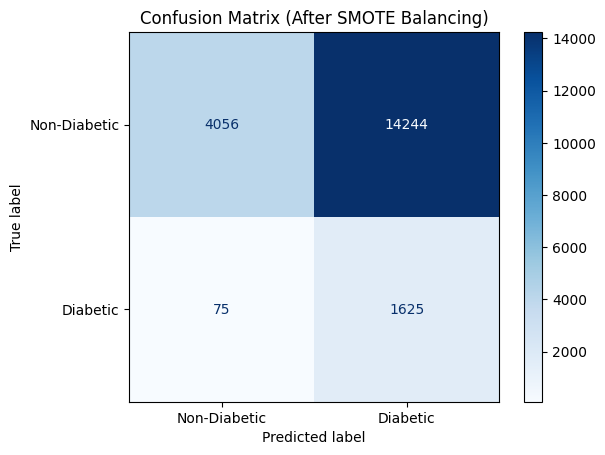

In [ ]:
# ===============================
# 5. Fix Class Imbalance + Evaluation
# ===============================
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Apply SMOTE only on the training data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_resampled))

# Retrain the model with balanced data
balanced_model = HRSModel(input_dim=X.shape[1])
optimizer = torch.optim.Adam(balanced_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop on resampled data
balanced_model.train()
epochs = 5
for epoch in range(epochs):
    inputs = torch.tensor(X_resampled, dtype=torch.float32)
    targets = torch.tensor(y_resampled, dtype=torch.long)
    optimizer.zero_grad()
    outputs = balanced_model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

# Evaluation on test data
balanced_model.eval()
X_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    outputs = balanced_model(X_tensor)
    preds = torch.argmax(outputs, axis=1).numpy()

print("\nClassification Report (After SMOTE Balancing):")
print(classification_report(y_test, preds, target_names=["Non-Diabetic", "Diabetic"]))

# Confusion Matrix
cm = confusion_matrix(y_test, preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (After SMOTE Balancing)")
plt.show()


/tmp/ipython-input-3639265074.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


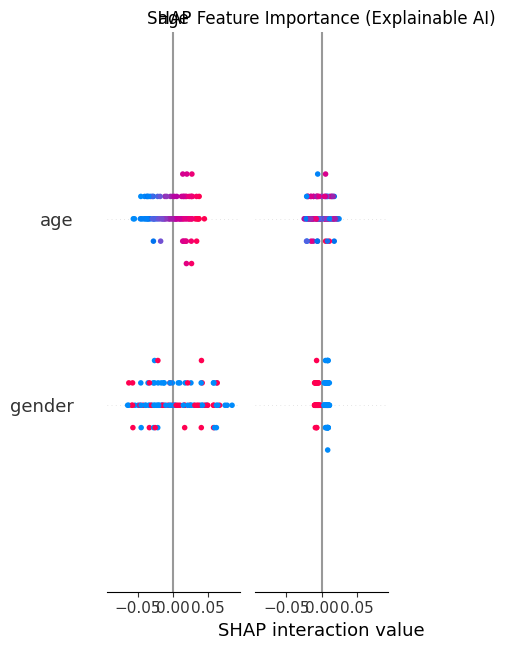

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

background = torch.tensor(X_train[:100], dtype=torch.float32)
X_sample = torch.tensor(X_test[:100], dtype=torch.float32)

explainer = shap.GradientExplainer(global_model, background)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_combined = np.mean(np.abs(np.array(shap_values)), axis=0)
else:
    shap_combined = shap_values

if isinstance(X_sample, torch.Tensor):
    X_sample = X_sample.detach().numpy()

shap.summary_plot(
    shap_combined,
    X_sample,
    feature_names=df.drop(columns=["diabetes"]).columns,
    show=False
)
plt.title("SHAP Feature Importance (Explainable AI)")
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download("federated_hrs_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>